In [43]:
import numpy as np 
from matplotlib import pyplot as plt 
import os, sys
from scipy.optimize import bisect

In [145]:
L = 1.0
Npart = 1e7
nx = 2**(int(round(np.log2(Npart**(1/3))))-1)
dx = L/nx
xvec = np.linspace(0+dx/2, L-dx/2, nx)
print(nx)

spectral_idx = -2.0

freqs = np.fft.fftfreq(nx, d=dx)

kx, ky, kz = np.meshgrid(freqs, freqs, freqs)
k = np.sqrt(kx**2 + ky**2 + kz**2)

densi_tilde = np.random.normal(size=(nx, nx, nx)) + 1j * np.random.normal(size=(nx, nx, nx))
densi_tilde *= k**spectral_idx
densi_tilde[0, 0, 0] = 0.0
densi = np.fft.ifftn(densi_tilde).real

densi -= densi.min()
densi /= densi.sum()
densi *= Npart

128


/home/valles/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in power
  


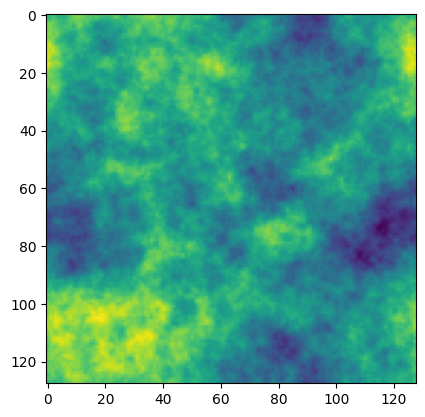

In [152]:
plt.imshow(densi[:, :, int(nx/2)].T, cmap='viridis')

In [153]:
def get_thr(thr, densi, Npart):
    return (densi/thr).astype(int).sum() - Npart
thr = bisect(get_thr, densi.min()+1e-6, densi.max(), args=(densi, Npart))
parts = (densi/thr).astype(int)

In [156]:
parts.sum()

10000000

(array([  1575.,  18091.,  96059., 291734., 508004., 525256., 399233.,
        203155.,  47812.,   6016.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5]),
 <BarContainer object of 10 artists>)

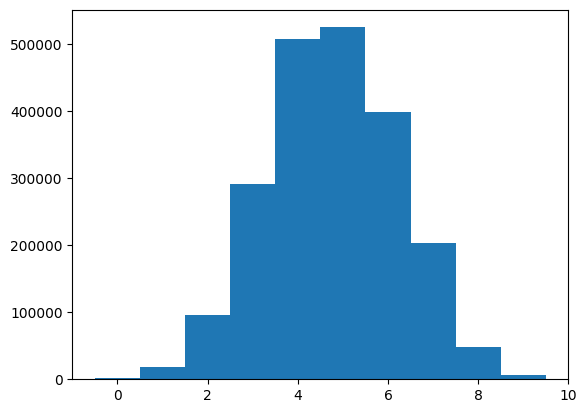

In [157]:
plt.hist(parts.flatten(), bins=np.arange(0,parts.max()+1)-0.5)

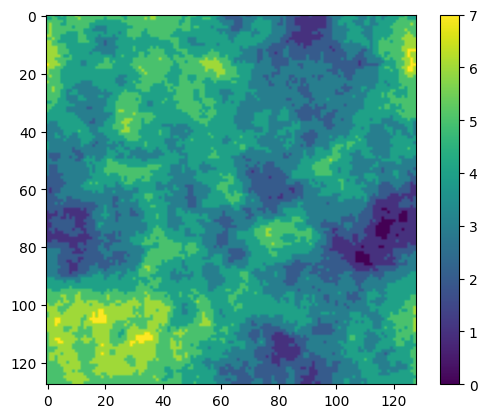

In [158]:
plt.imshow(parts[:, :, int(nx/2)].T, cmap='viridis')
plt.colorbar()

In [159]:
def get_thr(thr, densi, Npart):
    return (densi/thr).astype(int).sum() - Npart
thr = bisect(get_thr, densi.min()+1e-6, densi.max(), args=(densi, Npart))
parts = (densi/thr).astype(int)

xpart = [] 
ypart = []
zpart = []

for i in range(nx):
    for j in range(nx):
        for k in range(nx):
            npart = parts[i, j, k]
            if npart > 0:
                xpart += [np.random.uniform(xvec[i]-dx/2, xvec[i]+dx/2, npart)]
                ypart += [np.random.uniform(xvec[j]-dx/2, xvec[j]+dx/2, npart)]
                zpart += [np.random.uniform(xvec[k]-dx/2, xvec[k]+dx/2, npart)]

xpart = np.concatenate(xpart)
ypart = np.concatenate(ypart)
zpart = np.concatenate(zpart)

In [164]:
select.shape

(10000,)

In [165]:
select = (xvec[int(nx/2)]-dx/2<zpart) & (zpart<xvec[int(nx/2)]+dx/2)
if select.sum() > 1e4:
    # subsample only 10000
    true_locs = np.flatnonzero(select)
    selected = np.random.choice(true_locs, size=10000, replace=False)
    select[:] = False
    select[selected] = True
print(select.sum())

10000


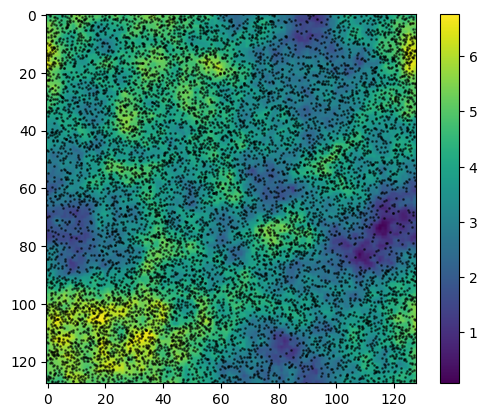

In [ ]:
plt.imshow(densi[:, :, int(nx/2)].T, cmap='viridis')
plt.colorbar()
plt.scatter(xpart[select]/dx - 0.5, ypart[select]/dx - 0.5, s=1, c='k', alpha=0.5)
#plt.contour(parts[:,:,int(nx/2)], levels=[10])
plt.gca().set_aspect(1)